#  Predicción de Pasajeros Aéreos con LSTM
## Electiva Profesional II – Deep Learning | UDEC Facatativá
#####Autor: Andres Felipe Diaz Campos
---

**Dataset:** Airline Passengers Dataset (1949–1960)  
**Modelo:** Long Short-Term Memory (LSTM) – Red Neuronal Recurrente  
**Objetivo:** Predecir la cantidad de pasajeros mensuales usando datos secuenciales históricos

---

###  Estructura del Notebook
1. Instalación e Importación de Librerías
2. Carga y Exploración del Dataset
3. Preprocesamiento y Normalización
4. Creación de Secuencias Temporales
5. División Train / Test
6. Arquitectura del Modelo LSTM
7. Entrenamiento del Modelo
8. Evaluación y Métricas
9. Visualización de Resultados
10. Análisis y Conclusiones

##  1. Instalación e Importación de Librerías

In [ ]:
# ============================================================
# BLOQUE 1: INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ============================================================
# Se instalan librerías adicionales para visualización profesional
# y manejo de datos.

!pip install plotly --quiet          # Gráficos interactivos
!pip install scikit-learn --quiet    # Métricas y preprocesamiento

# ── Librerías estándar ──────────────────────────────────────
import numpy as np                   # Operaciones numéricas y matriciales
import pandas as pd                  # Manipulación de DataFrames
import matplotlib.pyplot as plt      # Gráficos estáticos
import matplotlib.patches as mpatches
import seaborn as sns                # Visualización estadística
import warnings
warnings.filterwarnings('ignore')    # Silenciar advertencias menores

# ── Deep Learning (TensorFlow / Keras) ─────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,          # Capa principal: Long Short-Term Memory
    Dense,         # Capa totalmente conectada (salida)
    Dropout,       # Regularización: previene sobreajuste
    BatchNormalization,  # Normaliza las activaciones intermedias
    Input          # Capa de entrada explícita
)
from tensorflow.keras.callbacks import (
    EarlyStopping,      # Detiene el entrenamiento si no mejora
    ReduceLROnPlateau,  # Reduce el learning rate si el modelo estanca
    ModelCheckpoint     # Guarda el mejor modelo durante el entrenamiento
)
from tensorflow.keras.optimizers import Adam  # Optimizador adaptativo

# ── Preprocesamiento y métricas ─────────────────────────────
from sklearn.preprocessing import MinMaxScaler  # Normalización [0, 1]
from sklearn.metrics import (
    mean_squared_error,       # Error cuadrático medio (MSE)
    mean_absolute_error,      # Error absoluto medio (MAE)
    r2_score                  # Coeficiente de determinación R²
)

# ── Gráficos interactivos ───────────────────────────────────
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ── Configuración global de estilo ──────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')   # Estilo oscuro profesional
sns.set_palette('husl')                   # Paleta de colores
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ── Verificar versiones ─────────────────────────────────────
print('=' * 55)
print('   ENTORNO DE TRABAJO – VERSIONES DE LIBRERÍAS')
print('=' * 55)
print(f'  TensorFlow  : {tf.__version__}')
print(f'  NumPy       : {np.__version__}')
print(f'  Pandas      : {pd.__version__}')
print(f'  Seed global : {RANDOM_SEED}')
print('=' * 55)

   ENTORNO DE TRABAJO – VERSIONES DE LIBRERÍAS
  TensorFlow  : 2.19.0
  NumPy       : 2.0.2
  Pandas      : 2.2.2
  Seed global : 42


##  2. Carga y Exploración del Dataset

> El **Airline Passengers Dataset** contiene el número mensual de pasajeros
> de aerolíneas internacionales entre **enero de 1949** y **diciembre de 1960**.
> Es un clásico benchmark para series temporales con tendencia y estacionalidad.

In [ ]:
# ============================================================
# BLOQUE 2: CARGA Y EXPLORACIÓN DEL DATASET
# ============================================================
# El dataset se descarga directamente desde una URL pública.
# Alternativa: subir el CSV desde Kaggle manualmente.

URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'

# ── Carga del CSV ────────────────────────────────────────────
df = pd.read_csv(URL, header=0, names=['Mes', 'Pasajeros'])

# ── Conversión de la columna de fecha ───────────────────────
# Se parsea el formato 'YYYY-MM' a datetime para indexar la serie
df['Mes'] = pd.to_datetime(df['Mes'], format='%Y-%m')
df.set_index('Mes', inplace=True)

# ── Vista previa ─────────────────────────────────────────────
print('=' * 55)
print('   VISTA PREVIA DEL DATASET')
print('=' * 55)
print(df.head(12))   # Primer año completo
print()

# ── Información general ──────────────────────────────────────
print('=' * 55)
print('   INFORMACIÓN GENERAL')
print('=' * 55)
print(f'  Registros totales  : {len(df)}')
print(f'  Período            : {df.index.min().date()} → {df.index.max().date()}')
print(f'  Años cubiertos     : {df.index.year.nunique()}')
print(f'  Valores nulos      : {df.isnull().sum().values[0]}')
print()

# ── Estadísticas descriptivas ────────────────────────────────
print('=' * 55)
print('   ESTADÍSTICAS DESCRIPTIVAS')
print('=' * 55)
stats = df.describe().round(2)
print(stats)

   VISTA PREVIA DEL DATASET
            Pasajeros
Mes                  
1949-01-01        112
1949-02-01        118
1949-03-01        132
1949-04-01        129
1949-05-01        121
1949-06-01        135
1949-07-01        148
1949-08-01        148
1949-09-01        136
1949-10-01        119
1949-11-01        104
1949-12-01        118

   INFORMACIÓN GENERAL
  Registros totales  : 144
  Período            : 1949-01-01 → 1960-12-01
  Años cubiertos     : 12
  Valores nulos      : 0

   ESTADÍSTICAS DESCRIPTIVAS
       Pasajeros
count     144.00
mean      280.30
std       119.97
min       104.00
25%       180.00
50%       265.50
75%       360.50
max       622.00


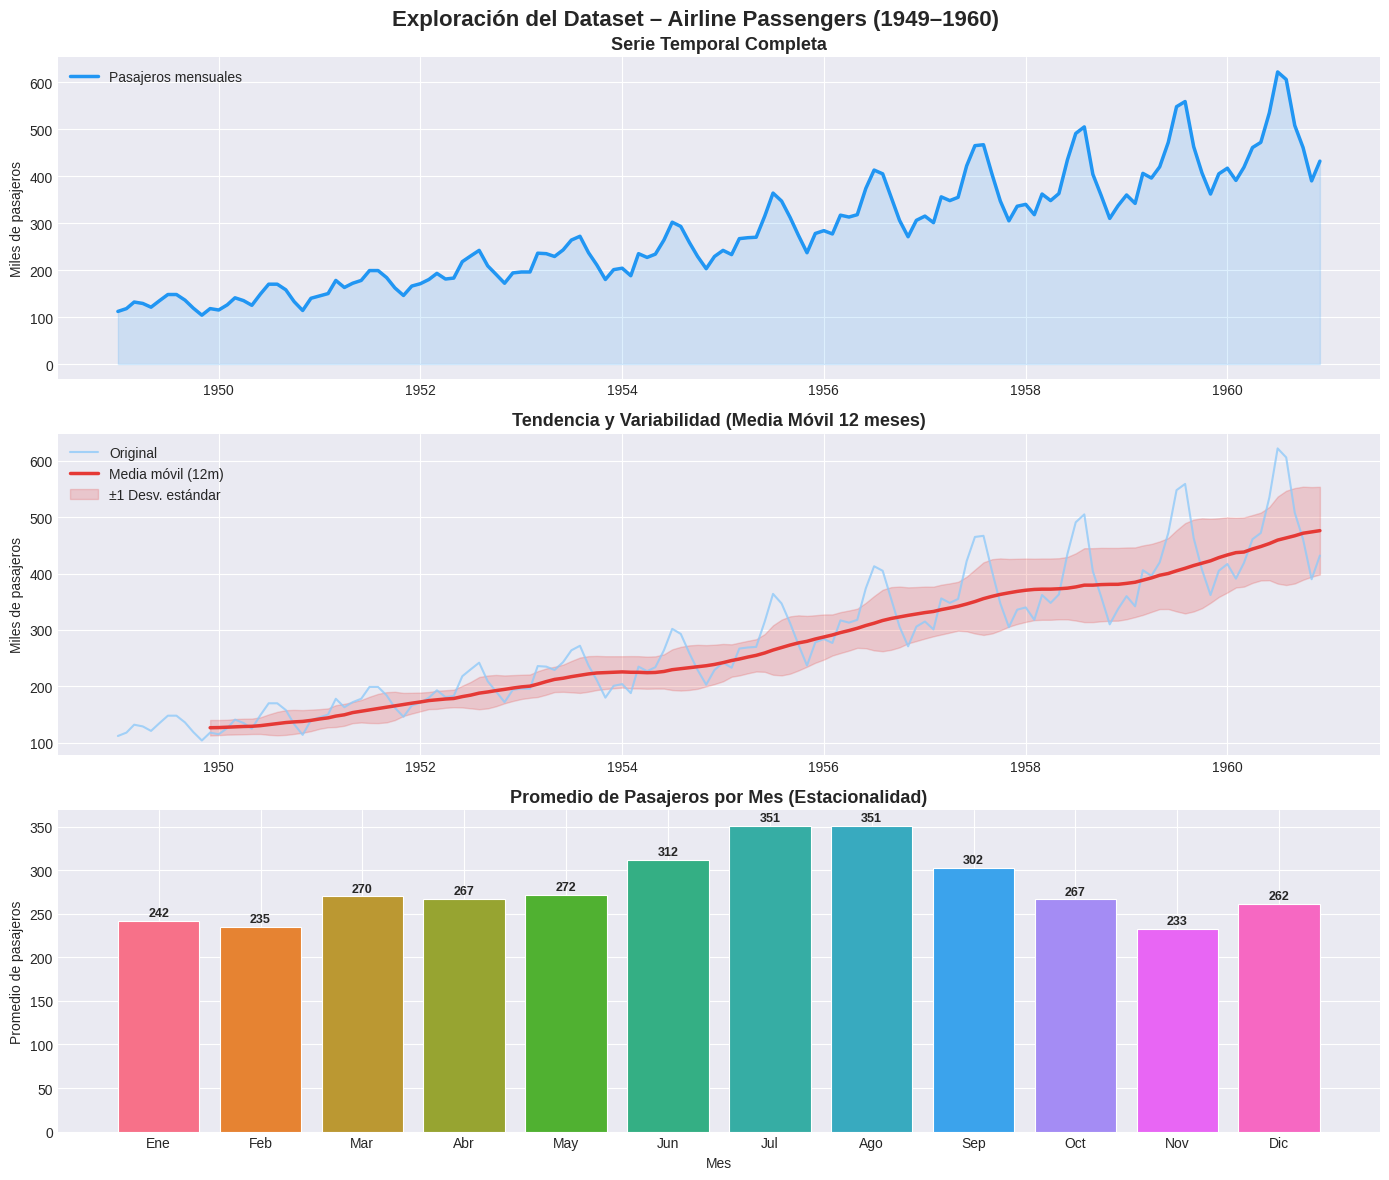

 Gráfico de exploración generado.


In [ ]:
# ============================================================
# BLOQUE 2B: VISUALIZACIÓN EXPLORATORIA INICIAL
# ============================================================
# Se generan 3 paneles para entender la serie antes de modelar.

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Exploración del Dataset – Airline Passengers (1949–1960)',
             fontsize=16, fontweight='bold', y=0.98)

# Panel 1: Serie temporal completa
axes[0].plot(df.index, df['Pasajeros'], color='#2196F3',
             linewidth=2.5, label='Pasajeros mensuales')
axes[0].fill_between(df.index, df['Pasajeros'], alpha=0.15, color='#2196F3')
axes[0].set_title('Serie Temporal Completa', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Miles de pasajeros')
axes[0].legend()
axes[0].set_xlabel('')

# Panel 2: Media móvil (tendencia) vs serie original
rolling_mean = df['Pasajeros'].rolling(window=12).mean()   # Media anual
rolling_std  = df['Pasajeros'].rolling(window=12).std()    # Desv. estándar
axes[1].plot(df.index, df['Pasajeros'], color='#90CAF9',
             linewidth=1.5, alpha=0.8, label='Original')
axes[1].plot(df.index, rolling_mean, color='#E53935',
             linewidth=2.5, label='Media móvil (12m)')
axes[1].fill_between(df.index,
                      rolling_mean - rolling_std,
                      rolling_mean + rolling_std,
                      alpha=0.2, color='#E53935', label='±1 Desv. estándar')
axes[1].set_title('Tendencia y Variabilidad (Media Móvil 12 meses)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Miles de pasajeros')
axes[1].legend()

# Panel 3: Distribución por mes del año (estacionalidad)
df_temp = df.copy()
df_temp['Mes_num'] = df_temp.index.month
df_temp['Año']     = df_temp.index.year
monthly_avg = df_temp.groupby('Mes_num')['Pasajeros'].mean()
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun',
                 'Jul','Ago','Sep','Oct','Nov','Dic']
bars = axes[2].bar(meses_nombres, monthly_avg.values,
                    color=sns.color_palette('husl', 12), edgecolor='white', linewidth=0.8)
axes[2].set_title('Promedio de Pasajeros por Mes (Estacionalidad)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Promedio de pasajeros')
axes[2].set_xlabel('Mes')
# Anotar valores sobre cada barra
for bar, val in zip(bars, monthly_avg.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('exploracion_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Gráfico de exploración generado.')

##  3. Preprocesamiento y Normalización

> Las redes LSTM son sensibles a la escala de los datos.
> Se aplica **MinMaxScaler** para llevar los valores al rango `[0, 1]`.

In [ ]:
# ============================================================
# BLOQUE 3: PREPROCESAMIENTO Y NORMALIZACIÓN
# ============================================================

# ── Extraer valores como array NumPy ────────────────────────
data_raw = df['Pasajeros'].values.astype('float32')
data_raw = data_raw.reshape(-1, 1)   # Shape: (144, 1)

# ── Normalización MinMax: escala los datos a [0, 1] ─────────
# Esto ayuda al gradiente a converger más rápido y evita
# que la LSTM sature sus funciones de activación (tanh, sigmoid).
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_raw)

print('=' * 55)
print('   PREPROCESAMIENTO')
print('=' * 55)
print(f'  Shape original  : {data_raw.shape}')
print(f'  Shape escalado  : {data_scaled.shape}')
print(f'  Mín original    : {data_raw.min():.0f} pasajeros')
print(f'  Máx original    : {data_raw.max():.0f} pasajeros')
print(f'  Mín normalizado : {data_scaled.min():.4f}')
print(f'  Máx normalizado : {data_scaled.max():.4f}')
print('=' * 55)
print(' Normalización completada.')

   PREPROCESAMIENTO
  Shape original  : (144, 1)
  Shape escalado  : (144, 1)
  Mín original    : 104 pasajeros
  Máx original    : 622 pasajeros
  Mín normalizado : 0.0000
  Máx normalizado : 1.0000
 Normalización completada.


##  4. Creación de Secuencias Temporales

> La LSTM aprende patrones en **ventanas deslizantes** de tiempo.
> Con `LOOK_BACK = 12` usamos los últimos 12 meses para predecir el siguiente.

In [ ]:
# ============================================================
# BLOQUE 4: CREACIÓN DE SECUENCIAS TEMPORALES (VENTANA DESLIZANTE)
# ============================================================
# La función create_sequences convierte la serie 1D en pares (X, y)
# donde X = ventana de 'look_back' pasos y y = valor siguiente.
#
#  Ejemplo con look_back=3:
#  [1, 2, 3] → predice → [4]
#  [2, 3, 4] → predice → [5]  ...

LOOK_BACK = 12   # 12 meses de historia para predecir 1 mes futuro

def create_sequences(data, look_back=12):
    """
    Genera pares de secuencias (X, y) para entrenamiento de RNN/LSTM.

    Parámetros:
    -----------
    data      : array normalizado de forma (n, 1)
    look_back : tamaño de la ventana temporal (número de pasos previos)

    Retorna:
    --------
    X : array de forma (samples, look_back, 1)  ← entrada de la LSTM
    y : array de forma (samples, 1)             ← salida esperada
    """
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i : i + look_back, 0])    # Ventana de historia
        y.append(data[i + look_back, 0])         # Valor objetivo
    X = np.array(X)
    y = np.array(y)
    # Reshape X a 3D: (muestras, pasos_temporales, características)
    # La LSTM espera siempre 3 dimensiones.
    X = X.reshape(X.shape[0], X.shape[1], 1)
    return X, y

X_all, y_all = create_sequences(data_scaled, LOOK_BACK)

print('=' * 55)
print('   SECUENCIAS GENERADAS')
print('=' * 55)
print(f'  Look-back (ventana)  : {LOOK_BACK} meses')
print(f'  Total de secuencias  : {len(X_all)}')
print(f'  Forma de X           : {X_all.shape}  → (muestras, pasos, features)')
print(f'  Forma de y           : {y_all.shape}  → (muestras,)')
print('=' * 55)
print(' Secuencias temporales creadas exitosamente.')

   SECUENCIAS GENERADAS
  Look-back (ventana)  : 12 meses
  Total de secuencias  : 132
  Forma de X           : (132, 12, 1)  → (muestras, pasos, features)
  Forma de y           : (132,)  → (muestras,)
 Secuencias temporales creadas exitosamente.


##  5. División Train / Test

   DIVISIÓN TRAIN / TEST
  Total secuencias  : 132
  Train (80%)       : 105 muestras
  Test  (20%)       : 27 muestras
  Forma X_train     : (105, 12, 1)
  Forma X_test      : (27, 12, 1)


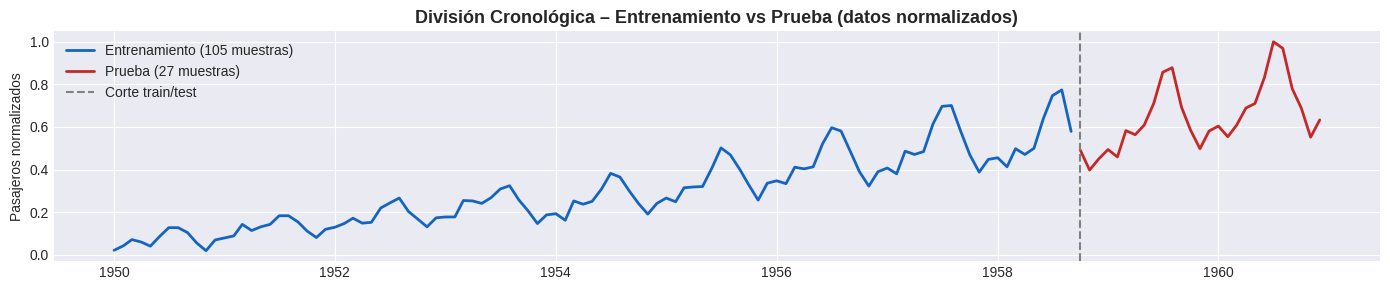

 División completada.


In [ ]:
# ============================================================
# BLOQUE 5: DIVISIÓN ENTRENAMIENTO / PRUEBA
# ============================================================
# En series temporales NO se mezclan aleatoriamente los datos.
# Se respeta el orden cronológico: primero se entrena, luego se prueba.
# División: 80% train – 20% test

TRAIN_RATIO = 0.80
train_size  = int(len(X_all) * TRAIN_RATIO)

X_train = X_all[:train_size]
X_test  = X_all[train_size:]
y_train = y_all[:train_size]
y_test  = y_all[train_size:]

print('=' * 55)
print('   DIVISIÓN TRAIN / TEST')
print('=' * 55)
print(f'  Total secuencias  : {len(X_all)}')
print(f'  Train (80%)       : {len(X_train)} muestras')
print(f'  Test  (20%)       : {len(X_test)} muestras')
print(f'  Forma X_train     : {X_train.shape}')
print(f'  Forma X_test      : {X_test.shape}')
print('=' * 55)

# ── Diagrama visual de la división ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
serie_idx = df.index[LOOK_BACK:]    # índices correspondientes a las secuencias
ax.plot(serie_idx[:train_size], y_train, color='#1565C0',
        linewidth=2, label=f'Entrenamiento ({train_size} muestras)')
ax.plot(serie_idx[train_size:], y_test,  color='#C62828',
        linewidth=2, label=f'Prueba ({len(y_test)} muestras)')
ax.axvline(serie_idx[train_size], color='gray', linestyle='--', linewidth=1.5, label='Corte train/test')
ax.set_title('División Cronológica – Entrenamiento vs Prueba (datos normalizados)', fontsize=13, fontweight='bold')
ax.set_ylabel('Pasajeros normalizados')
ax.legend()
plt.tight_layout()
plt.show()
print(' División completada.')

**texto en negrita**##  6. Arquitectura del Modelo LSTM

```
Input (12, 1)
    │
    ▼
LSTM (128 unidades, return_sequences=True)
    │
BatchNormalization + Dropout(0.3)
    │
    ▼
LSTM (64 unidades, return_sequences=False)
    │
BatchNormalization + Dropout(0.2)
    │
    ▼
Dense (32, relu)
    │
    ▼
Dense (1) ← Predicción
```

In [ ]:
# ============================================================
# BLOQUE 6: CONSTRUCCIÓN DE LA ARQUITECTURA LSTM
# ============================================================

def build_lstm_model(look_back, lstm1_units=128, lstm2_units=64,
                     dense_units=32, dropout_rate1=0.3,
                     dropout_rate2=0.2, learning_rate=0.001):
    """
    Construye y compila un modelo LSTM de dos capas para regresión.

    Parámetros:
    -----------
    look_back      : número de pasos temporales de entrada
    lstm1_units    : neuronas en la primera capa LSTM (extrae patrones generales)
    lstm2_units    : neuronas en la segunda capa LSTM (refinamiento)
    dense_units    : neuronas en la capa densa intermedia
    dropout_rate1  : tasa de dropout después de LSTM 1 (regularización)
    dropout_rate2  : tasa de dropout después de LSTM 2
    learning_rate  : paso de aprendizaje del optimizador Adam

    Retorna:
    --------
    model : modelo Keras compilado y listo para entrenar
    """
    model = Sequential(name='LSTM_AirlinePassengers')

    # ── Capa de entrada explícita ───────────────────────────
    model.add(Input(shape=(look_back, 1)))

    # ── Primera capa LSTM ───────────────────────────────────
    # return_sequences=True: pasa la secuencia completa a la siguiente LSTM
    model.add(LSTM(units=lstm1_units,
                   return_sequences=True,
                   name='LSTM_1'))
    model.add(BatchNormalization(name='BN_1'))  # Estabiliza el entrenamiento
    model.add(Dropout(rate=dropout_rate1, name='Dropout_1'))  # Previene sobreajuste

    # ── Segunda capa LSTM ───────────────────────────────────
    # return_sequences=False: devuelve solo el último estado oculto
    model.add(LSTM(units=lstm2_units,
                   return_sequences=False,
                   name='LSTM_2'))
    model.add(BatchNormalization(name='BN_2'))
    model.add(Dropout(rate=dropout_rate2, name='Dropout_2'))

    # ── Capa densa de procesamiento ─────────────────────────
    model.add(Dense(units=dense_units, activation='relu', name='Dense_1'))

    # ── Capa de salida (regresión) ──────────────────────────
    # Sin activación → valor continuo (predicción de pasajeros)
    model.add(Dense(units=1, name='Salida'))

    # ── Compilación ─────────────────────────────────────────
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='mse',               # Error cuadrático medio como función de pérdida
        metrics=['mae']           # También monitorear MAE durante el entrenamiento
    )
    return model


# ── Crear el modelo ──────────────────────────────────────────
model = build_lstm_model(look_back=LOOK_BACK)

# ── Mostrar resumen de la arquitectura ──────────────────────
print('=' * 55)
print('   ARQUITECTURA DEL MODELO LSTM')
print('=' * 55)
model.summary()
print()

# ── Contar parámetros ────────────────────────────────────────
total_params     = model.count_params()
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f'  Total de parámetros entrenables: {total_params:,}')

   ARQUITECTURA DEL MODELO LSTM


Model: "LSTM_AirlinePassengers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 12, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_1 (BatchNormalization)       │ (None, 12, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Salida (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,849 (464.25 KB)

 Trainable params: 118,465 (462.75 KB)

 Non-trainable params: 384 (1.50 KB)


  Total de parámetros entrenables: 118,849


##  7. Entrenamiento del Modelo

In [ ]:
# ============================================================
# BLOQUE 7: ENTRENAMIENTO DEL MODELO
# ============================================================
# Se definen callbacks para un entrenamiento inteligente:
#   - EarlyStopping   : para si val_loss no mejora en N épocas
#   - ReduceLROnPlateau: baja el lr si el modelo se estanca
#   - ModelCheckpoint : guarda el mejor modelo automáticamente

EPOCHS     = 150
BATCH_SIZE = 16
VAL_SPLIT  = 0.15   # 15% del train como validación

# ── Callbacks ────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=25,           # Espera 25 épocas sin mejora antes de parar
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,            # Reduce lr a la mitad
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='mejor_modelo_lstm.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print('=' * 55)
print('   INICIANDO ENTRENAMIENTO')
print('=' * 55)
print(f'  Épocas máximas  : {EPOCHS}')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Validación      : {VAL_SPLIT*100:.0f}% del train')
print('=' * 55)
print()

# ── Entrenamiento ─────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_split= VAL_SPLIT,
    callbacks       = callbacks,
    verbose         = 1
)

print()
print('=' * 55)
print(f'   Entrenamiento finalizado')
print(f'  Épocas ejecutadas : {len(history.history["loss"])}')
print(f'  Mejor val_loss    : {min(history.history["val_loss"]):.6f}')
print('=' * 55)

   INICIANDO ENTRENAMIENTO
  Épocas máximas  : 150
  Batch size      : 16
  Validación      : 15% del train

Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 381ms/step - loss: 0.7720 - mae: 0.6840 - val_loss: 0.2796 - val_mae: 0.5149 - learning_rate: 0.0010
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.3495 - mae: 0.4632 - val_loss: 0.2444 - val_mae: 0.4794 - learning_rate: 0.0010
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - loss: 0.2265 - mae: 0.3609 - val_loss: 0.2352 - val_mae: 0.4695 - learning_rate: 0.0010
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.1449 - mae: 0.2924 - val_loss: 0.2354 - val_mae: 0.4698 - learning_rate: 0.0010
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - loss: 0.1478 - mae: 0.2895 - val_loss: 0.2332 - val_mae: 0.4674 - learning_rate: 0.0010
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - loss: 0.1509 - mae: 0.3024 - val_loss: 0.2335 - val_mae: 0.4676 - learning_rate: 0.0010
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms

##  8. Evaluación y Métricas

In [ ]:
# ============================================================
# BLOQUE 8: EVALUACIÓN DEL MODELO Y MÉTRICAS
# ============================================================
# Se generan predicciones en escala original (desnormalizada)
# y se calculan métricas estándar de regresión.

# ── Predicciones en escala normalizada ──────────────────────
y_pred_train_norm = model.predict(X_train, verbose=0)
y_pred_test_norm  = model.predict(X_test,  verbose=0)

# ── Desnormalizar → valores reales de pasajeros ─────────────
y_pred_train = scaler.inverse_transform(y_pred_train_norm)
y_pred_test  = scaler.inverse_transform(y_pred_test_norm)
y_true_train = scaler.inverse_transform(y_train.reshape(-1, 1))
y_true_test  = scaler.inverse_transform(y_test.reshape(-1, 1))

# ── Cálculo de métricas ──────────────────────────────────────
def calcular_metricas(y_true, y_pred, nombre):
    """
    Calcula y muestra las métricas de evaluación:
    - RMSE : Raíz del error cuadrático medio (penaliza errores grandes)
    - MAE  : Error absoluto medio (interpretable en unidades originales)
    - MAPE : Error porcentual absoluto medio
    - R²   : Coeficiente de determinación (qué tan bien explica la varianza)
    """
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)

    print(f'  {nombre}')
    print(f'    RMSE : {rmse:.2f} pasajeros')
    print(f'    MAE  : {mae:.2f}  pasajeros')
    print(f'    MAPE : {mape:.2f} %')
    print(f'    R²   : {r2:.4f}')
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R2': r2}

print('=' * 55)
print('   MÉTRICAS DE EVALUACIÓN')
print('=' * 55)
metricas_train = calcular_metricas(y_true_train, y_pred_train, ' TRAIN')
print()
metricas_test  = calcular_metricas(y_true_test,  y_pred_test,  ' TEST')
print('=' * 55)

   MÉTRICAS DE EVALUACIÓN
   TRAIN
    RMSE : 45.76 pasajeros
    MAE  : 38.60  pasajeros
    MAPE : 16.87 %
    R²   : 0.7448

   TEST
    RMSE : 99.66 pasajeros
    MAE  : 78.25  pasajeros
    MAPE : 16.37 %
    R²   : -0.5637


## 9. Visualización de Resultados

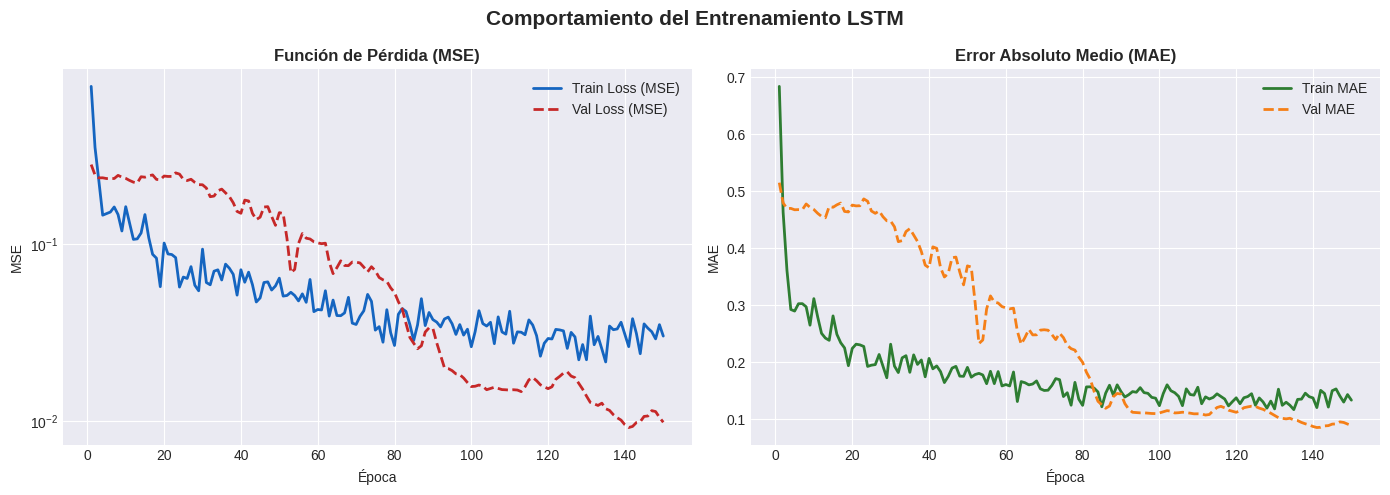

Curvas de entrenamiento generadas.


In [ ]:
# ============================================================
# BLOQUE 9A: CURVAS DE PÉRDIDA DURANTE EL ENTRENAMIENTO
# ============================================================
# Este gráfico permite detectar sobreajuste (overfitting):
# Si train_loss baja pero val_loss sube → el modelo está memorizando.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comportamiento del Entrenamiento LSTM',
             fontsize=15, fontweight='bold')

epochs_range = range(1, len(history.history['loss']) + 1)

# Pérdida (MSE)
axes[0].plot(epochs_range, history.history['loss'],
             color='#1565C0', linewidth=2, label='Train Loss (MSE)')
axes[0].plot(epochs_range, history.history['val_loss'],
             color='#C62828', linewidth=2, linestyle='--', label='Val Loss (MSE)')
axes[0].set_title('Función de Pérdida (MSE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].set_yscale('log')   # Escala logarítmica para mejor visualización

# MAE
axes[1].plot(epochs_range, history.history['mae'],
             color='#2E7D32', linewidth=2, label='Train MAE')
axes[1].plot(epochs_range, history.history['val_mae'],
             color='#F57F17', linewidth=2, linestyle='--', label='Val MAE')
axes[1].set_title('Error Absoluto Medio (MAE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curvas de entrenamiento generadas.')

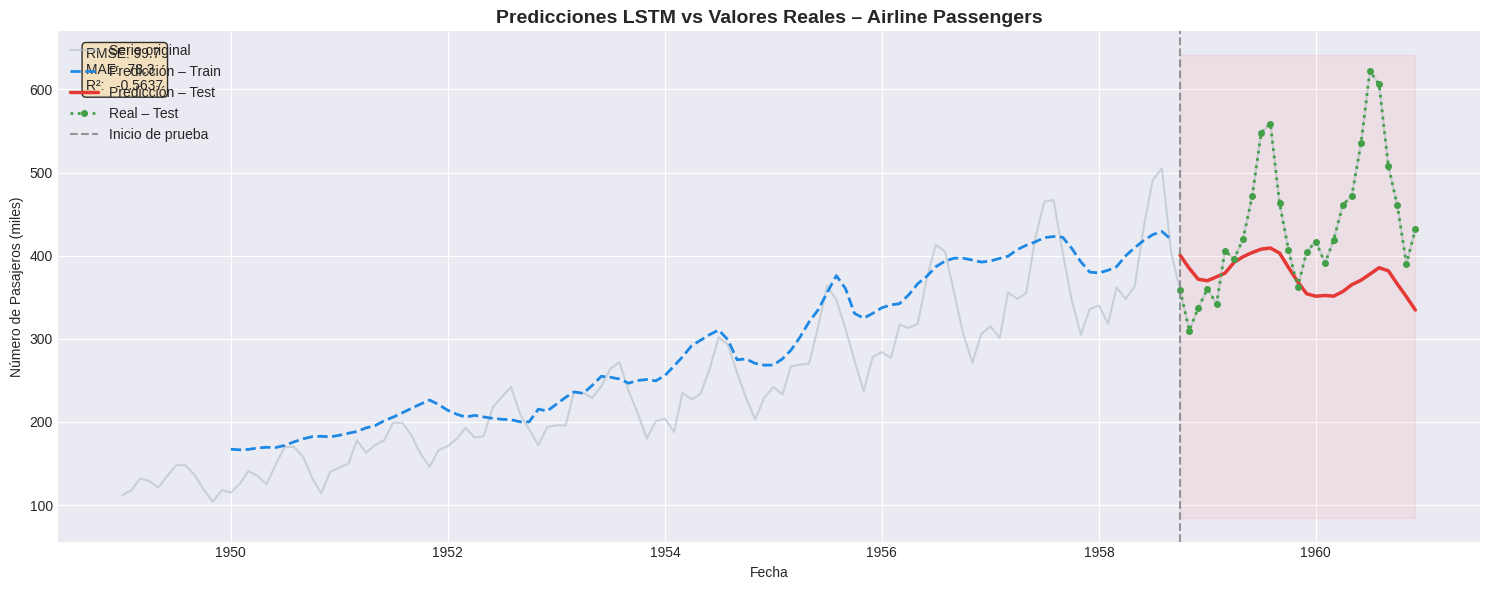

 Gráfico de predicciones generado.


In [ ]:
# ============================================================
# BLOQUE 9B: PREDICCIONES vs VALORES REALES
# ============================================================
# Comparación visual directa entre lo que el modelo predijo
# y los valores reales del dataset.

# ── Reconstruir el eje temporal ───────────────────────────────
fechas_total = df.index[LOOK_BACK:]
fechas_train = fechas_total[:train_size]
fechas_test  = fechas_total[train_size:]

fig, ax = plt.subplots(figsize=(15, 6))

# Serie original completa (referencia)
ax.plot(df.index, df['Pasajeros'],
        color='#B0BEC5', linewidth=1.5, alpha=0.6, label='Serie original')

# Predicciones de entrenamiento
ax.plot(fechas_train, y_pred_train.flatten(),
        color='#1E88E5', linewidth=2,
        linestyle='--', label='Predicción – Train')

# Predicciones de prueba
ax.plot(fechas_test, y_pred_test.flatten(),
        color='#E53935', linewidth=2.5, label='Predicción – Test')

# Valores reales de prueba
ax.plot(fechas_test, y_true_test.flatten(),
        color='#43A047', linewidth=2,
        linestyle=':', marker='o', markersize=4, label='Real – Test')

# Línea de corte
ax.axvline(fechas_test[0], color='gray',
           linestyle='--', linewidth=1.5, alpha=0.8, label='Inicio de prueba')
ax.fill_betweenx([df['Pasajeros'].min() - 20, df['Pasajeros'].max() + 20],
                  fechas_test[0], df.index[-1],
                  alpha=0.05, color='red')

ax.set_title('Predicciones LSTM vs Valores Reales – Airline Passengers',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Número de Pasajeros (miles)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left', fontsize=10)

# Anotar métricas en el gráfico
texto = (f"RMSE: {metricas_test['RMSE']:.1f}\n"
         f"MAE:  {metricas_test['MAE']:.1f}\n"
         f"R²:   {metricas_test['R2']:.4f}")
ax.text(0.02, 0.97, texto, transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('predicciones_vs_reales.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Gráfico de predicciones generado.')

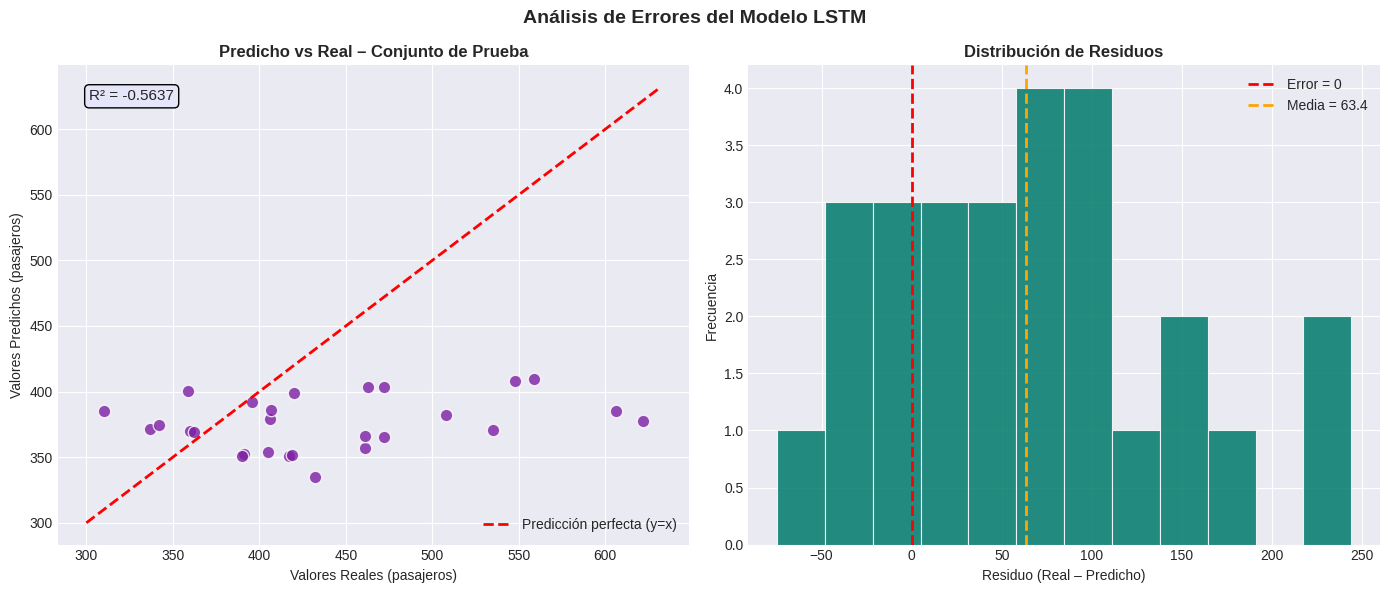

 Análisis de errores generado.


In [ ]:
# ============================================================
# BLOQUE 9C: SCATTER – PREDICHO vs REAL (sólo TEST)
# ============================================================
# Un buen modelo tendrá puntos cerca de la línea y = x (diagonal perfecta).

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Análisis de Errores del Modelo LSTM', fontsize=14, fontweight='bold')

# Gráfico de dispersión predicho vs real
axes[0].scatter(y_true_test, y_pred_test,
                color='#7B1FA2', alpha=0.8, edgecolors='white', s=80)
lim_min = min(y_true_test.min(), y_pred_test.min()) - 10
lim_max = max(y_true_test.max(), y_pred_test.max()) + 10
axes[0].plot([lim_min, lim_max], [lim_min, lim_max],
             'r--', linewidth=2, label='Predicción perfecta (y=x)')
axes[0].set_xlabel('Valores Reales (pasajeros)')
axes[0].set_ylabel('Valores Predichos (pasajeros)')
axes[0].set_title('Predicho vs Real – Conjunto de Prueba', fontweight='bold')
axes[0].legend()
axes[0].text(0.05, 0.95, f'R² = {metricas_test["R2"]:.4f}',
             transform=axes[0].transAxes, fontsize=11,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lavender'))

# Distribución de residuos
residuos = y_true_test.flatten() - y_pred_test.flatten()
axes[1].hist(residuos, bins=12, color='#00796B', edgecolor='white',
             alpha=0.85, linewidth=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Error = 0')
axes[1].axvline(residuos.mean(), color='orange', linestyle='--',
                linewidth=2, label=f'Media = {residuos.mean():.1f}')
axes[1].set_xlabel('Residuo (Real – Predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('analisis_errores.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Análisis de errores generado.')

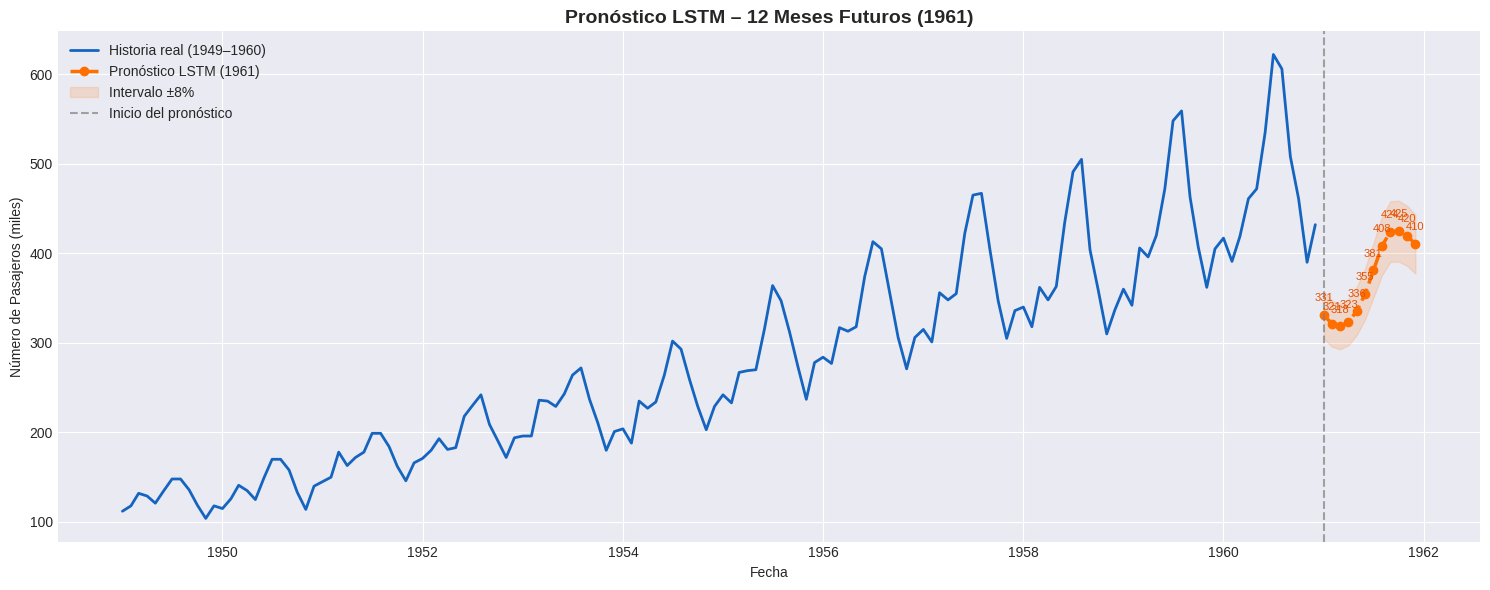

   PRONÓSTICO 1961 – 12 MESES FUTUROS
           Mes  Pasajeros Pronosticados
  January 1961                      330
 February 1961                      321
    March 1961                      318
    April 1961                      323
      May 1961                      335
     June 1961                      354
     July 1961                      380
   August 1961                      408
September 1961                      424
  October 1961                      424
 November 1961                      419
 December 1961                      410


In [ ]:
# ============================================================
# BLOQUE 9D: PREDICCIÓN FUTURA (PRONÓSTICO 12 MESES)
# ============================================================
# Se usa el modelo para predecir los 12 meses siguientes
# al período cubierto por el dataset (enero–diciembre 1961).

N_FUTURO = 12    # meses a pronosticar

# Última ventana de datos reales (ultimos 12 meses normalizados)
ultima_ventana = data_scaled[-LOOK_BACK:].reshape(1, LOOK_BACK, 1)

predicciones_futuras = []
ventana_actual = ultima_ventana.copy()

for _ in range(N_FUTURO):
    # Predecir el siguiente paso
    pred = model.predict(ventana_actual, verbose=0)[0, 0]
    predicciones_futuras.append(pred)
    # Desplazar la ventana: quitar el más antiguo, añadir la nueva predicción
    nueva_entrada = np.array([[[pred]]])
    ventana_actual = np.concatenate([ventana_actual[:, 1:, :], nueva_entrada], axis=1)

# Desnormalizar las predicciones
pred_futuras_reales = scaler.inverse_transform(
    np.array(predicciones_futuras).reshape(-1, 1)
)

# Crear fechas futuras (desde enero 1961)
ultima_fecha = df.index[-1]
fechas_futuras = pd.date_range(start=ultima_fecha + pd.DateOffset(months=1),
                               periods=N_FUTURO, freq='MS')

# ── Graficar el pronóstico ────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df.index, df['Pasajeros'],
        color='#1565C0', linewidth=2, label='Historia real (1949–1960)')
ax.plot(fechas_futuras, pred_futuras_reales.flatten(),
        color='#FF6F00', linewidth=2.5,
        linestyle='--', marker='o', markersize=6,
        label='Pronóstico LSTM (1961)')
ax.fill_between(fechas_futuras,
                pred_futuras_reales.flatten() * 0.92,
                pred_futuras_reales.flatten() * 1.08,
                alpha=0.15, color='#FF6F00', label='Intervalo ±8%')
ax.axvline(fechas_futuras[0], color='gray',
           linestyle='--', linewidth=1.5, alpha=0.7, label='Inicio del pronóstico')

ax.set_title('Pronóstico LSTM – 12 Meses Futuros (1961)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Número de Pasajeros (miles)')
ax.set_xlabel('Fecha')
ax.legend(loc='upper left', fontsize=10)

# Tabla de pronósticos
meses_nombres = ['Ene','Feb','Mar','Abr','May','Jun',
                 'Jul','Ago','Sep','Oct','Nov','Dic']
for i, (fecha, val) in enumerate(zip(fechas_futuras, pred_futuras_reales.flatten())):
    ax.annotate(f'{val:.0f}', (fecha, val),
                textcoords='offset points', xytext=(0, 10),
                fontsize=8, ha='center', color='#E65100')

plt.tight_layout()
plt.savefig('pronostico_futuro.png', dpi=150, bbox_inches='tight')
plt.show()

# Mostrar tabla de resultados futuros
df_futuro = pd.DataFrame({
    'Mes': [m.strftime('%B %Y') for m in fechas_futuras],
    'Pasajeros Pronosticados': pred_futuras_reales.flatten().astype(int)
})
print('=' * 45)
print('   PRONÓSTICO 1961 – 12 MESES FUTUROS')
print('=' * 45)
print(df_futuro.to_string(index=False))
print('=' * 45)

*texto en cursiva*##  10. Resumen Final y Conclusiones

> **¿Cómo usa la RNN/LSTM la información secuencial para predecir?**
>
> La LSTM procesa la ventana de 12 meses paso a paso.
> En cada paso `t` actualiza tres compuertas internas:
> - **Forget Gate**: decide qué información del pasado olvidar
> - **Input Gate**: decide qué nueva información guardar en la memoria de celda
> - **Output Gate**: decide qué parte de la memoria exponer como salida
>
> Al final de los 12 pasos, el vector de estado oculto `h₁₂`
> contiene un resumen comprimido de toda la historia,
> que la capa Dense transforma en la predicción del mes 13.

In [ ]:
# ============================================================
# BLOQUE 10: RESUMEN EJECUTIVO FINAL
# ============================================================

print()
print('╔' + '═'*53 + '╗')
print('║       RESUMEN EJECUTIVO – MODELO LSTM               ║')
print('╠' + '═'*53 + '╣')
print(f'║  Dataset        : Airline Passengers (1949–1960)    ║')
print(f'║  Arquitectura   : LSTM(128) → LSTM(64) → Dense(1)  ║')
print(f'║  Ventana (LB)   : {LOOK_BACK} meses                         ║')
print(f'║  Épocas         : {len(history.history["loss"]):<5}                        ║')
print('╠' + '═'*53 + '╣')
print('║              MÉTRICAS EN PRUEBA                     ║')
print('╠' + '═'*53 + '╣')
print(f'║  RMSE : {metricas_test["RMSE"]:>8.2f} pasajeros                   ║')
print(f'║  MAE  : {metricas_test["MAE"]:>8.2f} pasajeros                   ║')
print(f'║  MAPE : {metricas_test["MAPE"]:>8.2f} %                          ║')
print(f'║  R²   : {metricas_test["R2"]:>8.4f}                            ║')
print('╠' + '═'*53 + '╣')
print('║  Archivos generados:                                ║')
print('║   • exploracion_dataset.png                         ║')
print('║   • curvas_entrenamiento.png                        ║')
print('║   • predicciones_vs_reales.png                      ║')
print('║   • analisis_errores.png                            ║')
print('║   • pronostico_futuro.png                           ║')
print('║   • mejor_modelo_lstm.keras                         ║')
print('╚' + '═'*53 + '╝')
print()
print(' Notebook completado exitosamente.')


╔═════════════════════════════════════════════════════╗
║       RESUMEN EJECUTIVO – MODELO LSTM               ║
╠═════════════════════════════════════════════════════╣
║  Dataset        : Airline Passengers (1949–1960)    ║
║  Arquitectura   : LSTM(128) → LSTM(64) → Dense(1)  ║
║  Ventana (LB)   : 12 meses                         ║
║  Épocas         : 150                          ║
╠═════════════════════════════════════════════════════╣
║              MÉTRICAS EN PRUEBA                     ║
╠═════════════════════════════════════════════════════╣
║  RMSE :    99.66 pasajeros                   ║
║  MAE  :    78.25 pasajeros                   ║
║  MAPE :    16.37 %                          ║
║  R²   :  -0.5637                            ║
╠═════════════════════════════════════════════════════╣
║  Archivos generados:                                ║
║   • exploracion_dataset.png                         ║
║   • curvas_entrenamiento.png                        ║
║   • predicciones_vs_reales

In [ ]:
# ============================================================
# BLOQUE 11: DASHBOARD VISUAL INTERACTIVO – ENTRENAMIENTO LSTM
# ============================================================
# Pega este bloque en una celda nueva AL FINAL del notebook,
# después de haber ejecutado todos los bloques anteriores (1–10).
#
# Requisitos previos (variables que deben existir en el entorno):
#   - history           : objeto retornado por model.fit()
#   - fechas_train      : índice DatetimeIndex del conjunto train
#   - fechas_test       : índice DatetimeIndex del conjunto test
#   - fechas_futuras    : fechas del pronóstico 1961
#   - y_true_train, y_pred_train : valores reales y predichos (train)
#   - y_true_test,  y_pred_test  : valores reales y predichos (test)
#   - pred_futuras_reales        : pronóstico desnormalizado
#   - metricas_test     : dict con RMSE, MAE, MAPE, R2
# ============================================================

from IPython.display import display, HTML
import json

# ── Serializar datos de Python → JavaScript ──────────────────
# Convierte los arrays de NumPy / listas Python a JSON puro
# para que Chart.js los pueda consumir en el navegador de Colab.

train_loss_data = [float(v) for v in history.history['loss']]
val_loss_data   = [float(v) for v in history.history['val_loss']]
train_mae_data  = [float(v) for v in history.history['mae']]
val_mae_data    = [float(v) for v in history.history['val_mae']]
epochs_list     = list(range(1, len(train_loss_data) + 1))

# Fechas → strings ISO para los labels del eje X
fechas_str_train = [str(f.date()) for f in fechas_train]
fechas_str_test  = [str(f.date()) for f in fechas_test]
fechas_str_fut   = [str(f.date()) for f in fechas_futuras]

# Series de pasajeros (valores reales en escala original)
real_train_list = y_true_train.flatten().tolist()
pred_train_list = y_pred_train.flatten().tolist()
real_test_list  = y_true_test.flatten().tolist()
pred_test_list  = y_pred_test.flatten().tolist()
fut_list        = pred_futuras_reales.flatten().tolist()

# Métricas finales redondeadas
rmse_val          = round(metricas_test['RMSE'], 2)
mae_val           = round(metricas_test['MAE'],  2)
mape_val          = round(metricas_test['MAPE'], 2)
r2_val            = round(metricas_test['R2'],   4)
epocas_ejecutadas = len(train_loss_data)
pct_epocas        = round(epocas_ejecutadas / 150 * 100)
loss_train_final  = round(train_loss_data[-1], 6)
loss_val_final    = round(val_loss_data[-1],   6)

# ── Volcado JSON de todas las series ─────────────────────────
# Se hace una sola vez para no repetir json.dumps() dentro del f-string
J_epochs     = json.dumps(epochs_list)
J_trainLoss  = json.dumps(train_loss_data)
J_valLoss    = json.dumps(val_loss_data)
J_trainMAE   = json.dumps(train_mae_data)
J_valMAE     = json.dumps(val_mae_data)
J_fTrain     = json.dumps(fechas_str_train)
J_fTest      = json.dumps(fechas_str_test)
J_fFut       = json.dumps(fechas_str_fut)
J_realTrain  = json.dumps(real_train_list)
J_predTrain  = json.dumps(pred_train_list)
J_realTest   = json.dumps(real_test_list)
J_predTest   = json.dumps(pred_test_list)
J_fut        = json.dumps(fut_list)

# ── HTML del dashboard ────────────────────────────────────────
# Se usa un string normal (no f-string) para el bloque HTML/JS
# y se sustituyen los valores Python con .format() al final.
# Esto evita conflictos entre las llaves {{ }} de Python y las
# llaves { } de JavaScript / CSS.

HTML_TEMPLATE = """
<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.0/dist/chart.umd.min.js"></script>
<style>
  /* ── Reset y fuente base ── */
  * { margin:0; padding:0; box-sizing:border-box; }
  body {
    font-family: 'Segoe UI', system-ui, sans-serif;
    background: #0d0f1a;
    color: #e2e8f0;
    padding: 20px;
  }

  /* ══ HEADER ══════════════════════════════════════════════ */
  .header { text-align:center; margin-bottom:28px; }
  .header h1 {
    font-size: 1.7rem;
    font-weight: 700;
    background: linear-gradient(135deg,#60a5fa,#a78bfa,#34d399);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    letter-spacing: -0.5px;
  }
  .header p  { color:#64748b; font-size:0.85rem; margin-top:4px; }
  .badge {
    display:inline-block;
    background:#1e293b;
    border:1px solid #334155;
    border-radius:20px;
    padding:3px 12px;
    font-size:0.75rem;
    color:#94a3b8;
    margin-top:8px;
  }

  /* ══ TARJETAS DE MÉTRICAS ════════════════════════════════ */
  .metrics-grid {
    display:grid;
    grid-template-columns:repeat(4,1fr);
    gap:14px;
    margin-bottom:24px;
  }
  .metric-card {
    background:#111827;
    border:1px solid #1f2937;
    border-radius:14px;
    padding:18px 16px;
    text-align:center;
    position:relative;
    overflow:hidden;
    transition:transform .2s, border-color .2s;
  }
  .metric-card:hover { transform:translateY(-3px); border-color:#374151; }
  .metric-card::before {
    content:'';
    position:absolute;
    top:0; left:0; right:0;
    height:3px;
    border-radius:14px 14px 0 0;
  }
  .mc-blue::before   { background:linear-gradient(90deg,#3b82f6,#60a5fa); }
  .mc-purple::before { background:linear-gradient(90deg,#8b5cf6,#a78bfa); }
  .mc-green::before  { background:linear-gradient(90deg,#10b981,#34d399); }
  .mc-amber::before  { background:linear-gradient(90deg,#f59e0b,#fbbf24); }
  .metric-icon  { font-size:1.4rem; margin-bottom:6px; }
  .metric-label {
    font-size:0.7rem;
    color:#6b7280;
    text-transform:uppercase;
    letter-spacing:1px;
    margin-bottom:6px;
  }
  .metric-value { font-size:1.6rem; font-weight:700; line-height:1; }
  .mc-blue   .metric-value { color:#60a5fa; }
  .mc-purple .metric-value { color:#a78bfa; }
  .mc-green  .metric-value { color:#34d399; }
  .mc-amber  .metric-value { color:#fbbf24; }
  .metric-sub { font-size:0.68rem; color:#4b5563; margin-top:4px; }

  /* ══ FILA DE INFO ADICIONAL ══════════════════════════════ */
  .info-row {
    display:grid;
    grid-template-columns:repeat(3,1fr);
    gap:14px;
    margin-bottom:24px;
  }
  .info-card {
    background:#111827;
    border:1px solid #1f2937;
    border-radius:14px;
    padding:16px;
  }
  .info-card h3 {
    font-size:0.72rem;
    color:#6b7280;
    text-transform:uppercase;
    letter-spacing:1px;
    margin-bottom:12px;
  }

  /* ── Arquitectura de la red ── */
  .arch-flow { display:flex; align-items:center; gap:6px; flex-wrap:wrap; }
  .arch-layer {
    background:#1e293b;
    border:1px solid #334155;
    border-radius:8px;
    padding:6px 10px;
    font-size:0.7rem;
    text-align:center;
    flex:1;
    min-width:55px;
  }
  .arch-layer span { display:block; font-size:0.6rem; color:#6b7280; margin-top:2px; }
  .al-lstm  { border-color:#3b82f6; color:#60a5fa; }
  .al-bn    { border-color:#8b5cf6; color:#a78bfa; }
  .al-drop  { border-color:#f59e0b; color:#fbbf24; }
  .al-dense { border-color:#10b981; color:#34d399; }
  .al-out   { border-color:#ef4444; color:#f87171; }
  .arch-arrow { color:#374151; font-size:0.9rem; }

  /* ── Barra de épocas ── */
  .epoch-bar-bg {
    background:#1e293b;
    border-radius:99px;
    height:8px;
    overflow:hidden;
    margin:8px 0 4px;
  }
  .epoch-bar-fill {
    height:100%;
    border-radius:99px;
    background:linear-gradient(90deg,#3b82f6,#8b5cf6);
  }
  .epoch-stats {
    display:flex;
    justify-content:space-between;
    font-size:0.68rem;
    color:#6b7280;
    margin-top:4px;
  }
  .kv-row {
    display:flex;
    justify-content:space-between;
    font-size:0.72rem;
    margin-top:6px;
  }

  /* ── Grilla de pronóstico ── */
  .forecast-grid {
    display:grid;
    grid-template-columns:repeat(4,1fr);
    gap:6px;
    margin-top:4px;
  }
  .forecast-item {
    background:#1e293b;
    border-radius:8px;
    padding:6px 8px;
    text-align:center;
  }
  .fi-mes { font-size:0.6rem; color:#6b7280; margin-bottom:2px; }
  .fi-val { font-size:0.82rem; font-weight:600; color:#fb923c; }

  /* ══ GRÁFICOS ════════════════════════════════════════════ */
  .charts-row {
    display:grid;
    grid-template-columns:1fr 1fr;
    gap:14px;
    margin-bottom:24px;
  }
  .chart-card, .chart-full {
    background:#111827;
    border:1px solid #1f2937;
    border-radius:14px;
    padding:20px;
  }
  .chart-full { margin-bottom:24px; }
  .chart-card h2, .chart-full h2 {
    font-size:0.8rem;
    font-weight:600;
    color:#94a3b8;
    text-transform:uppercase;
    letter-spacing:1px;
    margin-bottom:14px;
  }
  canvas { max-height:260px; }

  /* ── Tabs ── */
  .tab-bar { display:flex; gap:8px; margin-bottom:14px; }
  .tab-btn {
    background:#1e293b;
    border:1px solid #334155;
    border-radius:8px;
    padding:5px 14px;
    font-size:0.75rem;
    color:#94a3b8;
    cursor:pointer;
    transition:all .2s;
  }
  .tab-btn.active { background:#1d4ed8; border-color:#3b82f6; color:#fff; }

  /* ══ FOOTER ══════════════════════════════════════════════ */
  .footer {
    text-align:center;
    padding:16px;
    font-size:0.7rem;
    color:#374151;
    border-top:1px solid #1f2937;
    margin-top:8px;
  }
</style>
</head>
<body>

<!-- ══ HEADER ══════════════════════════════════════════════ -->
<div class="header">
  <h1>🛫 Dashboard &mdash; Entrenamiento LSTM</h1>
  <p>Airline Passengers Dataset &middot; Predicción de Series Temporales</p>
  <span class="badge">UDEC Facatativá &middot; Electiva Profesional II &ndash; Deep Learning</span>
</div>

<!-- ══ TARJETAS DE MÉTRICAS ════════════════════════════════ -->
<div class="metrics-grid">

  <div class="metric-card mc-blue">
    <div class="metric-icon">📉</div>
    <div class="metric-label">RMSE</div>
    <div class="metric-value">RMSE_VAL</div>
    <div class="metric-sub">pasajeros &middot; conjunto test</div>
  </div>

  <div class="metric-card mc-purple">
    <div class="metric-icon">🎯</div>
    <div class="metric-label">MAE</div>
    <div class="metric-value">MAE_VAL</div>
    <div class="metric-sub">pasajeros &middot; error medio absoluto</div>
  </div>

  <div class="metric-card mc-green">
    <div class="metric-icon">✅</div>
    <div class="metric-label">R² Score</div>
    <div class="metric-value">R2_VAL</div>
    <div class="metric-sub">coeficiente de determinación</div>
  </div>

  <div class="metric-card mc-amber">
    <div class="metric-icon">📊</div>
    <div class="metric-label">MAPE</div>
    <div class="metric-value">MAPE_VAL%</div>
    <div class="metric-sub">error porcentual absoluto medio</div>
  </div>

</div>

<!-- ══ FILA: ARQUITECTURA + ÉPOCAS + PRONÓSTICO ════════════ -->
<div class="info-row">

  <!-- Arquitectura -->
  <div class="info-card">
    <h3>🧠 Arquitectura de la red</h3>
    <div class="arch-flow">
      <div class="arch-layer al-lstm">Input<span>(12, 1)</span></div>
      <span class="arch-arrow">→</span>
      <div class="arch-layer al-lstm">LSTM<span>128 u.</span></div>
      <span class="arch-arrow">→</span>
      <div class="arch-layer al-bn">BN<span>norm.</span></div>
      <span class="arch-arrow">→</span>
      <div class="arch-layer al-drop">Drop<span>0.30</span></div>
      <span class="arch-arrow">→</span>
      <div class="arch-layer al-lstm">LSTM<span>64 u.</span></div>
      <span class="arch-arrow">→</span>
      <div class="arch-layer al-bn">BN<span>norm.</span></div>
      <span class="arch-arrow">→</span>
      <div class="arch-layer al-drop">Drop<span>0.20</span></div>
      <span class="arch-arrow">→</span>
      <div class="arch-layer al-dense">Dense<span>32, relu</span></div>
      <span class="arch-arrow">→</span>
      <div class="arch-layer al-out">Out<span>1 neurona</span></div>
    </div>
  </div>

  <!-- Progreso del entrenamiento -->
  <div class="info-card">
    <h3>⚙️ Progreso del entrenamiento</h3>
    <div class="epoch-bar-bg">
      <div class="epoch-bar-fill" style="width:PCT_EPOCAS%"></div>
    </div>
    <div class="epoch-stats">
      <span>Épocas ejecutadas: <strong style="color:#60a5fa">EPOCAS_EXEC</strong></span>
      <span>Máximo: 150</span>
    </div>
    <div class="kv-row">
      <span style="color:#6b7280">Loss final (train)</span>
      <span style="color:#60a5fa;font-weight:600">LOSS_TRAIN</span>
    </div>
    <div class="kv-row">
      <span style="color:#6b7280">Loss final (val)</span>
      <span style="color:#a78bfa;font-weight:600">LOSS_VAL</span>
    </div>
    <div class="kv-row">
      <span style="color:#6b7280">Optimizador</span>
      <span style="color:#34d399;font-weight:600">Adam (lr=0.001)</span>
    </div>
    <div class="kv-row">
      <span style="color:#6b7280">Función de pérdida</span>
      <span style="color:#fbbf24;font-weight:600">MSE</span>
    </div>
    <div class="kv-row">
      <span style="color:#6b7280">Batch size</span>
      <span style="color:#f87171;font-weight:600">16</span>
    </div>
  </div>

  <!-- Pronóstico 1961 -->
  <div class="info-card">
    <h3>🔮 Pronóstico 1961 (12 meses)</h3>
    <div class="forecast-grid" id="forecast-grid"></div>
  </div>

</div>

<!-- ══ GRÁFICOS DE ENTRENAMIENTO ═══════════════════════════ -->
<div class="charts-row">
  <div class="chart-card">
    <h2>📉 Curva de pérdida (MSE)</h2>
    <canvas id="lossChart"></canvas>
  </div>
  <div class="chart-card">
    <h2>📐 Error absoluto medio (MAE)</h2>
    <canvas id="maeChart"></canvas>
  </div>
</div>

<!-- ══ GRÁFICO PRINCIPAL: PREDICCIONES ═════════════════════ -->
<div class="chart-full">
  <h2>🛫 Predicciones vs valores reales</h2>
  <div class="tab-bar">
    <button class="tab-btn active" onclick="switchTab('all',this)">Todo el período</button>
    <button class="tab-btn"        onclick="switchTab('test',this)">Solo test</button>
    <button class="tab-btn"        onclick="switchTab('forecast',this)">Pronóstico 1961</button>
  </div>
  <canvas id="predChart" style="max-height:300px"></canvas>
</div>

<!-- ══ FOOTER ══════════════════════════════════════════════ -->
<div class="footer">
  Electiva Profesional II &ndash; Deep Learning &middot; UDEC Facatativá &middot;
  Modelo: LSTM &middot; Dataset: Airline Passengers (1949&ndash;1960)
</div>

<!-- ══ JAVASCRIPT ══════════════════════════════════════════ -->
<script>
// ── Datos inyectados desde Python ──────────────────────────
const epochs     = JS_EPOCHS;
const trainLoss  = JS_TRAIN_LOSS;
const valLoss    = JS_VAL_LOSS;
const trainMAE   = JS_TRAIN_MAE;
const valMAE     = JS_VAL_MAE;

const fechasTrain = JS_F_TRAIN;
const fechasTest  = JS_F_TEST;
const fechasFut   = JS_F_FUT;

const realTrain  = JS_REAL_TRAIN;
const predTrain  = JS_PRED_TRAIN;
const realTest   = JS_REAL_TEST;
const predTest   = JS_PRED_TEST;
const futVals    = JS_FUT;

const meses1961  = ['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'];

// ── Configuración global de Chart.js ───────────────────────
Chart.defaults.color           = '#6b7280';
Chart.defaults.font.family     = "'Segoe UI', system-ui, sans-serif";
Chart.defaults.font.size       = 11;

const gridColor = 'rgba(255,255,255,0.04)';

// Devuelve la configuración de ejes para los gráficos de entrenamiento
function trainingAxes(yLabel) {
  return {
    x: {
      grid:  { color: gridColor },
      title: { display:true, text:'Época', color:'#4b5563' }
    },
    y: {
      grid:  { color: gridColor },
      title: { display:true, text:yLabel, color:'#4b5563' },
      ticks: { callback: v => v.toExponential(1) }
    }
  };
}

// ── 1. Gráfico de pérdida (MSE) ────────────────────────────
// Train vs Val Loss por época — divergencia creciente = overfitting
new Chart(document.getElementById('lossChart'), {
  type: 'line',
  data: {
    labels: epochs,
    datasets: [
      {
        label: 'Train Loss',
        data: trainLoss,
        borderColor: '#3b82f6',
        backgroundColor: 'rgba(59,130,246,0.08)',
        borderWidth: 2,
        pointRadius: 0,
        tension: 0.4,
        fill: true
      },
      {
        label: 'Val Loss',
        data: valLoss,
        borderColor: '#a78bfa',
        backgroundColor: 'rgba(167,139,250,0.06)',
        borderWidth: 2,
        pointRadius: 0,
        tension: 0.4,
        fill: true,
        borderDash: [5,4]
      }
    ]
  },
  options: {
    responsive: true,
    animation: { duration:1200, easing:'easeInOutQuart' },
    plugins: {
      legend:  { labels: { color:'#94a3b8', boxWidth:12 } },
      tooltip: { mode:'index', intersect:false }
    },
    scales: trainingAxes('MSE')
  }
});

// ── 2. Gráfico de MAE ──────────────────────────────────────
// Más interpretable que MSE: está en las mismas unidades
// que los datos normalizados (pasajeros escalados a [0,1]).
new Chart(document.getElementById('maeChart'), {
  type: 'line',
  data: {
    labels: epochs,
    datasets: [
      {
        label: 'Train MAE',
        data: trainMAE,
        borderColor: '#10b981',
        backgroundColor: 'rgba(16,185,129,0.08)',
        borderWidth: 2,
        pointRadius: 0,
        tension: 0.4,
        fill: true
      },
      {
        label: 'Val MAE',
        data: valMAE,
        borderColor: '#f59e0b',
        backgroundColor: 'rgba(245,158,11,0.06)',
        borderWidth: 2,
        pointRadius: 0,
        tension: 0.4,
        fill: true,
        borderDash: [5,4]
      }
    ]
  },
  options: {
    responsive: true,
    animation: { duration:1400, easing:'easeInOutQuart' },
    plugins: {
      legend:  { labels: { color:'#94a3b8', boxWidth:12 } },
      tooltip: { mode:'index', intersect:false }
    },
    scales: trainingAxes('MAE')
  }
});

// ── 3. Gráfico principal de predicciones (tabs) ────────────
// Tab "Todo el período" : historia completa + pronóstico naranja
// Tab "Solo test"       : zoom en predicción vs real en test
// Tab "Pronóstico 1961" : 12 meses futuros con área sombreada

let predChart;

function buildAllData() {
  const n = fechasTrain.length + fechasTest.length;
  return {
    labels: [...fechasTrain, ...fechasTest, ...fechasFut],
    datasets: [
      {
        label: 'Real',
        data:  [...realTrain, ...realTest, ...Array(fechasFut.length).fill(null)],
        borderColor: '#94a3b8',
        borderWidth: 1.5,
        pointRadius: 0,
        tension: 0.3
      },
      {
        label: 'Predicción',
        data:  [...predTrain, ...predTest, ...Array(fechasFut.length).fill(null)],
        borderColor: '#3b82f6',
        borderWidth: 2,
        pointRadius: 0,
        tension: 0.3,
        borderDash: [6,3]
      },
      {
        label: 'Pronóstico 1961',
        data:  [...Array(n).fill(null), ...futVals],
        borderColor: '#fb923c',
        backgroundColor: 'rgba(251,146,60,0.1)',
        borderWidth: 2.5,
        pointRadius: 4,
        pointBackgroundColor: '#fb923c',
        tension: 0.3,
        fill: true
      }
    ]
  };
}

function buildTestData() {
  return {
    labels: fechasTest,
    datasets: [
      {
        label: 'Real (test)',
        data:  realTest,
        borderColor: '#34d399',
        borderWidth: 2,
        pointRadius: 4,
        pointBackgroundColor: '#34d399',
        tension: 0.3
      },
      {
        label: 'Predicción (test)',
        data:  predTest,
        borderColor: '#ef4444',
        borderWidth: 2,
        pointRadius: 4,
        pointBackgroundColor: '#ef4444',
        tension: 0.3,
        borderDash: [5,4]
      }
    ]
  };
}

function buildForecastData() {
  return {
    labels: meses1961,
    datasets: [{
      label: 'Pronóstico 1961',
      data:  futVals,
      borderColor: '#fb923c',
      backgroundColor: 'rgba(251,146,60,0.15)',
      borderWidth: 2.5,
      pointRadius: 6,
      pointBackgroundColor: '#fb923c',
      tension: 0.4,
      fill: true
    }]
  };
}

const predOptions = {
  responsive: true,
  animation: { duration:900, easing:'easeInOutCubic' },
  plugins: {
    legend:  { labels: { color:'#94a3b8', boxWidth:12 } },
    tooltip: { mode:'index', intersect:false }
  },
  scales: {
    x: {
      grid:  { color: gridColor },
      ticks: { maxTicksLimit:10, maxRotation:30 }
    },
    y: {
      grid:  { color: gridColor },
      title: { display:true, text:'Pasajeros (miles)', color:'#4b5563' }
    }
  }
};

// Inicializar con la vista completa
predChart = new Chart(document.getElementById('predChart'), {
  type: 'line',
  data: buildAllData(),
  options: predOptions
});

// Cambiar de tab: destruye y recrea el chart con los datos correspondientes
function switchTab(tab, btn) {
  document.querySelectorAll('.tab-btn').forEach(b => b.classList.remove('active'));
  btn.classList.add('active');
  predChart.destroy();
  const data = tab === 'all'      ? buildAllData()
             : tab === 'test'     ? buildTestData()
             :                      buildForecastData();
  predChart = new Chart(document.getElementById('predChart'), {
    type: 'line', data: data, options: predOptions
  });
}

// ── 4. Grilla de pronóstico ────────────────────────────────
// Genera dinámicamente una tarjeta por cada mes de 1961
const grid = document.getElementById('forecast-grid');
futVals.forEach((v, i) => {
  const div = document.createElement('div');
  div.className = 'forecast-item';
  div.innerHTML = '<div class="fi-mes">' + meses1961[i] + '</div>'
                + '<div class="fi-val">' + Math.round(v) + '</div>';
  grid.appendChild(div);
});
</script>
</body>
</html>
"""

# ── Sustituir marcadores con valores reales de Python ────────
# Usamos marcadores de texto simple (MAYUSCULAS_CON_GUION)
# en lugar de {variables} para evitar conflictos con CSS/JS.
html_final = (HTML_TEMPLATE
    .replace('RMSE_VAL',    str(rmse_val))
    .replace('MAE_VAL',     str(mae_val))
    .replace('R2_VAL',      str(r2_val))
    .replace('MAPE_VAL',    str(mape_val))
    .replace('PCT_EPOCAS',  str(pct_epocas))
    .replace('EPOCAS_EXEC', str(epocas_ejecutadas))
    .replace('LOSS_TRAIN',  str(loss_train_final))
    .replace('LOSS_VAL',    str(loss_val_final))
    # Series JSON para JavaScript
    .replace('JS_EPOCHS',     J_epochs)
    .replace('JS_TRAIN_LOSS', J_trainLoss)
    .replace('JS_VAL_LOSS',   J_valLoss)
    .replace('JS_TRAIN_MAE',  J_trainMAE)
    .replace('JS_VAL_MAE',    J_valMAE)
    .replace('JS_F_TRAIN',    J_fTrain)
    .replace('JS_F_TEST',     J_fTest)
    .replace('JS_F_FUT',      J_fFut)
    .replace('JS_REAL_TRAIN', J_realTrain)
    .replace('JS_PRED_TRAIN', J_predTrain)
    .replace('JS_REAL_TEST',  J_realTest)
    .replace('JS_PRED_TEST',  J_predTest)
    .replace('JS_FUT',        J_fut)
)

# ── Renderizar en Colab ───────────────────────────────────────
# display(HTML(...)) embebe el HTML directamente en la celda de salida.
# Chart.js se carga desde CDN al renderizar; necesitas conexión a internet.
display(HTML(html_final))

print()
print(' Dashboard interactivo generado exitosamente.')
print('   Usa las pestañas del gráfico principal para explorar:')
print('   • Todo el período  – visión completa train + test + pronóstico')
print('   • Solo test        – zoom en las predicciones vs valores reales')
print('   • Pronóstico 1961  – los 12 meses futuros estimados por la LSTM')


 Dashboard interactivo generado exitosamente.
   Usa las pestañas del gráfico principal para explorar:
   • Todo el período  – visión completa train + test + pronóstico
   • Solo test        – zoom en las predicciones vs valores reales
   • Pronóstico 1961  – los 12 meses futuros estimados por la LSTM
